**Subquestion 4:** to what extent do seasonal differences in PM2.5 levels and weather conditions change inference performance?

* Winter: December, January, February
* Spring: March, April, May
* Summer: June, July, August
* Autumn: September, October, November


## 1. Settings and paths

In [ ]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from scipy.stats import wilcoxon

# imputed station CSVs and the station coordinates location
DATA_DIR = r"C:\Users\Storm Anderson\Documents\UVA\Inferencing\XGboost\data_imputed"
COORDS_CSV = r"C:\Users\Storm Anderson\Documents\UVA\Inferencing\XGboost\station_cell_map.csv"

# outputs 
OUT_TABLES = os.path.join("results", "tables")
OUT_FIGURES = os.path.join("results", "figures")
os.makedirs(OUT_TABLES, exist_ok=True)
os.makedirs(OUT_FIGURES, exist_ok=True)

# time split
TRAIN_YEAR_MAX = 2022   
VAL_YEAR = 2023         
TEST_YEAR = 2024        

USE_GPU = True          # set to False on a pc without an NVIDIA GPU

# Optuna tuned hyperparameters
PARAMS = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "max_depth": 5,
    "learning_rate": 0.050174637405817,
    "min_child_weight": 11,
    "subsample": 0.5982185916706947,
    "colsample_bytree": 0.7254529566891234,
    "reg_lambda": 0.5349747167608838,
    "reg_alpha": 3.625170550327679,
    "gamma": 1.605431841969294,
    "tree_method": "hist",
    "seed": 42,
    "device": "cuda" if USE_GPU else "cpu",
}
N_ROUNDS = 2000     # maximum number of boosting rounds
EARLY_STOP = 50     # early stopping patience on the 2023 validation year

K_NEAREST = 5       # neighbors used for nb_1 to nb_5, idw_neighbor and the wind cones
K_QUAD = 8          # neighbors used for the quadratic surface fit
IDW_POWER = 2.0     # inverse distance weighting power
LAG_HOURS = [1, 3, 6, 24]

pd.set_option("display.max_columns", None)
print("device:", PARAMS["device"])

device: cuda


## 2. Feature groups (69 features in six groups)

In [2]:
# the six feature groups, using the column names of the station CSVs
NETWORK_FEATURES = [
    "nb_1", "nb_2", "nb_3", "nb_4", "nb_5",
    "idw_neighbor",
    "nb1_lag_1h", "nb1_lag_3h", "nb1_lag_6h", "nb1_lag_24h",
    "nb1_24h_mean", "nb1_24h_std",
    "pm_upwind", "pm_downwind", "n_upwind", "n_downwind",
    "pm_gradient", "pm_advection", "pm_diffusion",
    "pm_upwind_isna", "pm_downwind_isna",
]

LCS_FEATURES = ["lcs_adv", "lcs_adv_coef", "f_rh", "lcs_x_frh", "lcs_rh_corrected"]

ERA5_FEATURES = [
    "t2m", "rh", "wind_speed", "wind_dir_sin", "wind_dir_cos",
    "sp", "ssr", "strd", "tp", "slhf", "sshf",
    "blh", "low_blh", "ventilation_coef", "stagnant", "stagnation_hours",
]

EAC4_FEATURES = [
    "aod550", "bcaod550", "duaod550", "ssaod550", "gtco3", "pm2p5",
    "co_1000hPa", "go3_1000hPa", "no2_1000hPa", "so2_1000hPa",
    "co_700hPa", "go3_700hPa", "no2_700hPa", "so2_700hPa",
    "co_500hPa", "go3_500hPa", "no2_500hPa", "so2_500hPa",
]

GEO_FEATURES = ["lat", "lon"]

TIME_FEATURES = ["hour_sin", "hour_cos", "doy_sin", "doy_cos", "dow_sin", "dow_cos", "year"]

ALL_FEATURES = (NETWORK_FEATURES + LCS_FEATURES + ERA5_FEATURES
                + EAC4_FEATURES + GEO_FEATURES + TIME_FEATURES)

print("features per group: network", len(NETWORK_FEATURES), "| lcs", len(LCS_FEATURES),
      "| era5", len(ERA5_FEATURES), "| eac4", len(EAC4_FEATURES),
      "| geo", len(GEO_FEATURES), "| time", len(TIME_FEATURES))
print("total features:", len(ALL_FEATURES))

# columns every fold table keeps next to the features
# lcs_median_pm25 is only used by the raw model in the ablation notebook
# the loop avoids duplicate columns, year is both an id column and a time feature
KEEP_COLS = ["station_id", "datetime", "year", "month", "ref_pm25", "lcs_median_pm25"]
for col in ALL_FEATURES:
    if col not in KEEP_COLS:
        KEEP_COLS.append(col)
print("columns per fold table:", len(KEEP_COLS))

features per group: network 21 | lcs 5 | era5 16 | eac4 18 | geo 2 | time 7
total features: 69
columns per fold table: 74


## 3. Load the data

In [3]:
t0 = time.time()
station_folders = sorted(os.listdir(DATA_DIR))

stations = {}
for folder in station_folders:
    folder_path = os.path.join(DATA_DIR, folder)
    if not os.path.isdir(folder_path):
        continue  # skips loose files like imputation_report.csv
    df = pd.read_csv(os.path.join(folder_path, folder + ".csv"))
    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df.sort_values("datetime").reset_index(drop=True)
    df["station_id"] = folder
    stations[folder] = df

STATION_IDS = list(stations.keys())

# station coordinates, also used as the geo features lat and lon
coords = pd.read_csv(COORDS_CSV)
coords = coords[coords["station_id"].isin(STATION_IDS)].set_index("station_id")[["lat", "lon"]]

for name in STATION_IDS:
    stations[name]["lat"] = coords.loc[name, "lat"]
    stations[name]["lon"] = coords.loc[name, "lon"]

# panel of the imputed reference PM2.5: rows are hours, columns are stations
# every neighbor feature below reads from this panel
panel = pd.DataFrame()
for name in STATION_IDS:
    df = stations[name]
    panel[name] = pd.Series(df["ref_pm25"].values, index=df["datetime"])
panel = panel.sort_index()

print("stations:", len(stations), "| panel shape:", panel.shape,
      "| loaded in", round(time.time() - t0, 1), "s")

stations: 31 | panel shape: (35064, 31) | loaded in 14.0 s


## 4. Helper functions

Geometry, rebuild of the neighbor features, the fold builder, the
train function and the metric functions. These cells are identical in notebooks 01 to 04

In [4]:
def haversine_km(lon1, lat1, lon2, lat2):
    R = 6371.0
    p1 = np.radians(lat1)
    p2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2.0) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlam / 2.0) ** 2
    return 2.0 * R * np.arcsin(np.sqrt(a))


def bearing_rad(lat1, lon1, lat2, lon2):
    # compass bearing from point 1 to point 2, in radians from north, clockwise
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dlon = np.radians(lon2 - lon1)
    x = np.sin(dlon) * np.cos(phi2)
    y = np.cos(phi1) * np.sin(phi2) - np.sin(phi1) * np.cos(phi2) * np.cos(dlon)
    return np.mod(np.arctan2(x, y), 2.0 * np.pi)


def angle_diff(a, b):
    # shortest signed angle a minus b, in [-pi, pi]
    return np.mod(a - b + np.pi, 2.0 * np.pi) - np.pi


def nearest_neighbors(target_id, available_ids, k):
    # the k nearest stations to target_id, chosen only from available_ids, never itself
    lat0 = coords.loc[target_id, "lat"]
    lon0 = coords.loc[target_id, "lon"]
    rows = []
    for other in available_ids:
        if other == target_id:
            continue
        lat1 = coords.loc[other, "lat"]
        lon1 = coords.loc[other, "lon"]
        rows.append({
            "id": other,
            "lat": lat1,
            "lon": lon1,
            "dist_km": float(haversine_km(lon0, lat0, lon1, lat1)),
            "bearing_rad": float(bearing_rad(lat0, lon0, lat1, lon1)),
        })
    rows.sort(key=lambda r: r["dist_km"])
    return rows[:k]

In [5]:
def rebuild_network_features(station_id, df_station, available_ids):
    # Returns a copy of the station table in which every neighbor derived feature is recomputed from only the stations 
    # in available_ids. This is the leakage control. The held out station (and any station removed by a distance band) is not in
    # available_ids, so its measurements cannot reach any feature in this fold. The formulas are same in to the feature 
    # engineering notebook. Values that cannot be computed stay NaN, XGBoost handles NaN natively.
    df = df_station.copy()
    n = len(df)
    meta5 = nearest_neighbors(station_id, available_ids, K_NEAREST)
    meta8 = nearest_neighbors(station_id, available_ids, K_QUAD)

    # neighbor readings nb_1 to nb_5
    for i in range(K_NEAREST):
        if i < len(meta5):
            df["nb_" + str(i + 1)] = panel[meta5[i]["id"]].reindex(df["datetime"]).values
        else:
            df["nb_" + str(i + 1)] = np.nan

    # inverse distance weighted mean of the neighbor readings
    num = np.zeros(n)
    den = np.zeros(n)
    for i in range(len(meta5)):
        d = max(meta5[i]["dist_km"], 0.1)
        w = 1.0 / d ** IDW_POWER
        vals = df["nb_" + str(i + 1)].values
        ok = ~np.isnan(vals)
        num = num + np.where(ok, vals * w, 0.0)
        den = den + np.where(ok, w, 0.0)
    with np.errstate(invalid="ignore", divide="ignore"):
        df["idw_neighbor"] = np.where(den > 0, num / den, np.nan)

    # lagged block from the nearest neighbor (left closed, so no future values)
    if len(meta5) > 0:
        nb1 = panel[meta5[0]["id"]]
        for h in LAG_HOURS:
            df["nb1_lag_" + str(h) + "h"] = nb1.reindex(df["datetime"] - pd.Timedelta(hours=h)).values
        roll_mean = nb1.rolling("24h", closed="left", min_periods=12).mean()
        roll_std = nb1.rolling("24h", closed="left", min_periods=12).std()
        df["nb1_24h_mean"] = roll_mean.reindex(df["datetime"]).values
        df["nb1_24h_std"] = roll_std.reindex(df["datetime"]).values
    else:
        for h in LAG_HOURS:
            df["nb1_lag_" + str(h) + "h"] = np.nan
        df["nb1_24h_mean"] = np.nan
        df["nb1_24h_std"] = np.nan

    # upwind and downwind neighbor averages (120 degree cones)
    cone_half_rad = np.radians(60.0)
    theta_to = np.mod(np.arctan2(df["u10"].values, df["v10"].values), 2.0 * np.pi)
    theta_from = np.mod(theta_to + np.pi, 2.0 * np.pi)
    up_num = np.zeros(n)
    up_den = np.zeros(n)
    up_count = np.zeros(n, dtype=int)
    dn_num = np.zeros(n)
    dn_den = np.zeros(n)
    dn_count = np.zeros(n, dtype=int)
    for i in range(len(meta5)):
        pm = df["nb_" + str(i + 1)].values
        valid = ~np.isnan(pm)
        w = 1.0 / max(meta5[i]["dist_km"], 0.1)
        beta = meta5[i]["bearing_rad"]
        in_up = (np.abs(angle_diff(beta, theta_from)) <= cone_half_rad) & valid
        in_dn = (np.abs(angle_diff(beta, theta_to)) <= cone_half_rad) & valid
        up_num = up_num + np.where(in_up, pm * w, 0.0)
        up_den = up_den + np.where(in_up, w, 0.0)
        up_count = up_count + in_up.astype(int)
        dn_num = dn_num + np.where(in_dn, pm * w, 0.0)
        dn_den = dn_den + np.where(in_dn, w, 0.0)
        dn_count = dn_count + in_dn.astype(int)
    with np.errstate(invalid="ignore", divide="ignore"):
        df["pm_upwind"] = np.where(up_den > 0, up_num / up_den, np.nan)
        df["pm_downwind"] = np.where(dn_den > 0, dn_num / dn_den, np.nan)
    df["n_upwind"] = up_count
    df["n_downwind"] = dn_count

    # convection diffusion terms from a quadratic surface fit on the 8 nearest
    if len(meta8) > 0:
        lat0 = coords.loc[station_id, "lat"]
        lon0 = coords.loc[station_id, "lon"]
        A = np.zeros((len(meta8), 6))
        for i in range(len(meta8)):
            dx = (meta8[i]["lon"] - lon0) * 111.32 * np.cos(np.radians(lat0))
            dy = (meta8[i]["lat"] - lat0) * 110.57
            A[i, 0] = 1.0
            A[i, 1] = dx
            A[i, 2] = dy
            A[i, 3] = dx * dx
            A[i, 4] = dy * dy
            A[i, 5] = dx * dy
        A_pinv = np.linalg.pinv(A)
        values = np.zeros((n, len(meta8)))
        for i in range(len(meta8)):
            values[:, i] = panel[meta8[i]["id"]].reindex(df["datetime"]).values
        coef = values @ A_pinv.T
        bad = np.isnan(values).any(axis=1)
        coef[bad, :] = np.nan
        grad_x = coef[:, 1]
        grad_y = coef[:, 2]
        df["pm_gradient"] = np.sqrt(grad_x ** 2 + grad_y ** 2)
        df["pm_advection"] = -(df["u10"].values * grad_x + df["v10"].values * grad_y) * 3.6
        df["pm_diffusion"] = 2.0 * coef[:, 3] + 2.0 * coef[:, 4]
    else:
        df["pm_gradient"] = np.nan
        df["pm_advection"] = np.nan
        df["pm_diffusion"] = np.nan

    # missing indicators for the two cone features
    df["pm_upwind_isna"] = df["pm_upwind"].isna().astype(int)
    df["pm_downwind_isna"] = df["pm_downwind"].isna().astype(int)
    return df

In [6]:
def build_fold_table(held_out, radius_km):
    # Builds the data for one LOSO fold. The held out station never appears in the training set and is never 
    # a candidate. For the distance bands every station within radius_km of the held out station is removed from the fold
    # completely: its rows leave the training set and it stops being a candidate for everyone. All remaining 
    # stations get rebuilt neighbor features, so nothing from the held out or removed stations can leak in.
    lat0 = coords.loc[held_out, "lat"]
    lon0 = coords.loc[held_out, "lon"]

    removed = []
    for other in STATION_IDS:
        if other == held_out:
            continue
        d = float(haversine_km(lon0, lat0, coords.loc[other, "lon"], coords.loc[other, "lat"]))
        if radius_km > 0 and d <= radius_km:
            removed.append(other)

    available = []
    for s in STATION_IDS:
        if s != held_out and s not in removed:
            available.append(s)

    # with the real 31 station network at least 5 stations always remain, even at 60 km
    if len(available) == 0:
        raise ValueError("radius " + str(radius_km) + " km removes every station around " + held_out)

    # training set (pool): every available station with rebuilt neighbor features
    pool_parts = []
    for s in available:
        rebuilt = rebuild_network_features(s, stations[s], available)
        pool_parts.append(rebuilt[KEEP_COLS])
    pool = pd.concat(pool_parts, ignore_index=True)

    # held out test rows: features rebuilt from the available network only
    test = rebuild_network_features(held_out, stations[held_out], available)
    test = test[test["year"] == TEST_YEAR]
    test = test[KEEP_COLS].reset_index(drop=True)

    return pool, test, removed

In [7]:
def train_one_fold(pool, test, feature_list):
    # Train on 2021 to 2022, find the number of rounds with early stopping on 2023,
    # refit on 2021 to 2023 with that number of rounds, then predict the 2024 test rows. 
    train = pool[pool["year"] <= TRAIN_YEAR_MAX]
    val = pool[pool["year"] == VAL_YEAR]
    refit = pool[pool["year"] <= VAL_YEAR]

    dtrain = xgb.DMatrix(train[feature_list], label=train["ref_pm25"])
    dval = xgb.DMatrix(val[feature_list], label=val["ref_pm25"])
    booster = xgb.train(PARAMS, dtrain, num_boost_round=N_ROUNDS,
                        evals=[(dval, "val")], early_stopping_rounds=EARLY_STOP,
                        verbose_eval=False)
    best_rounds = booster.best_iteration + 1

    drefit = xgb.DMatrix(refit[feature_list], label=refit["ref_pm25"])
    final = xgb.train(PARAMS, drefit, num_boost_round=best_rounds, verbose_eval=False)

    y_pred = final.predict(xgb.DMatrix(test[feature_list]))
    return y_pred, best_rounds

In [8]:
def compute_metrics(y_true, y_pred):
    # RMSE, MAE and R2 on the rows where both values exist
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ok = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true = y_true[ok]
    y_pred = y_pred[ok]
    if len(y_true) == 0:
        return {"n_hours": 0, "RMSE": np.nan, "MAE": np.nan, "R2": np.nan}
    err = y_pred - y_true
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    ss_res = float(np.sum(err ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    if ss_tot > 0:
        r2 = 1.0 - ss_res / ss_tot
    else:
        r2 = np.nan
    return {"n_hours": int(len(y_true)), "RMSE": rmse, "MAE": mae, "R2": r2}


def hourly_metrics_table(pred_df):
    # RMSE, MAE and R2 across the held out stations, for every evaluated hour
    rows = []
    for dt_value, group in pred_df.groupby("datetime"):
        m = compute_metrics(group["y_true"], group["y_pred"])
        rows.append({"datetime": dt_value, "n_stations": m["n_hours"],
                     "RMSE": m["RMSE"], "MAE": m["MAE"], "R2": m["R2"]})
    out = pd.DataFrame(rows).sort_values("datetime").reset_index(drop=True)
    return out


def bh_correction(p_values):
    # BH correction
    p = pd.Series(p_values, dtype=float)
    m = p.notna().sum()
    q = (p * m / p.rank(method="first")).clip(upper=1.0)
    return q

## 5. Run the LOSO loop (full model, intact network)

In [ ]:
per_station_rows = []
pred_parts = []
t0 = time.time()

for k, held_out in enumerate(STATION_IDS):
    pool, test, removed = build_fold_table(held_out, radius_km=0)
    y_pred, best_rounds = train_one_fold(pool, test, ALL_FEATURES)

    preds = test[["station_id", "datetime", "ref_pm25"]].copy()
    preds = preds.rename(columns={"ref_pm25": "y_true"})
    preds["y_pred"] = y_pred
    pred_parts.append(preds)

    m = compute_metrics(preds["y_true"], preds["y_pred"])
    m["station_id"] = held_out
    m["best_rounds"] = best_rounds
    per_station_rows.append(m)

    minutes = (time.time() - t0) / 60.0
    print("[%2d/%d] %s: RMSE %.3f | %.1f min" % (k + 1, len(STATION_IDS), held_out, m["RMSE"], minutes))

predictions = pd.concat(pred_parts, ignore_index=True)
per_station = pd.DataFrame(per_station_rows)
per_station = per_station[["station_id", "n_hours", "RMSE", "MAE", "R2", "best_rounds"]]
print()
print("overall mean station RMSE %.3f | MAE %.3f | R2 %.3f"
      % (per_station["RMSE"].mean(), per_station["MAE"].mean(), per_station["R2"].mean()))

[ 1/31] NL01485_PM2.5_lucht: RMSE 3.449 | 0.3 min
[ 2/31] NL01487_PM2.5_lucht: RMSE 2.798 | 0.5 min
[ 3/31] NL01488_PM2.5_lucht: RMSE 1.640 | 0.7 min
[ 4/31] NL01489_PM2.5_lucht: RMSE 1.479 | 0.9 min
[ 5/31] NL01491_PM2.5_lucht: RMSE 1.872 | 1.1 min
[ 6/31] NL01494_PM2.5_lucht: RMSE 2.336 | 1.4 min
[ 7/31] NL01496_PM2.5_lucht: RMSE 3.908 | 1.6 min
[ 8/31] NL01912_PM2.5_lucht: RMSE 1.660 | 1.8 min
[ 9/31] NL10136_PM2.5_lucht: RMSE 5.871 | 2.0 min
[10/31] NL10418_PM2.5_lucht: RMSE 3.491 | 2.2 min
[11/31] NL10449_PM2.5_lucht: RMSE 7.621 | 2.4 min
[12/31] NL10636_PM2.5_lucht: RMSE 3.394 | 2.6 min
[13/31] NL10643_PM2.5_lucht: RMSE 4.301 | 2.9 min
[14/31] NL10738_PM2.5_lucht: RMSE 3.934 | 3.0 min
[15/31] NL10741_PM2.5_lucht: RMSE 5.186 | 3.3 min
[16/31] NL10742_PM2.5_lucht: RMSE 4.501 | 3.5 min
[17/31] NL10821_PM2.5_lucht: RMSE 6.534 | 3.7 min
[18/31] NL10937_PM2.5_lucht: RMSE 4.376 | 3.9 min
[19/31] NL10938_PM2.5_lucht: RMSE 4.440 | 4.1 min
[20/31] NL49007_PM2.5_lucht: RMSE 3.110 | 4.3 min


## 6. Save the overall result tables

In [10]:
per_station.round(4).to_csv(os.path.join(OUT_TABLES, "sq4_per_station_metrics.csv"), index=False)

hourly = hourly_metrics_table(predictions)
hourly.to_csv(os.path.join(OUT_TABLES, "sq4_hourly_metrics.csv"), index=False, float_format="%.4f")

predictions.to_csv(os.path.join(OUT_TABLES, "sq4_predictions.csv"), index=False, float_format="%.4f")

print("saved the per station, hourly and prediction tables with the sq4_ prefix")

saved the per station, hourly and prediction tables with the sq4_ prefix


## 7. Seasonal table 
Metrics per season and station first, then averaged over the 31 stations. The normalized RMSE divides the mean RMSE by the mean concentration of that season, so errors can be compared across seasons with different pollution levels.

In [ ]:
SEASON_OF_MONTH = {12: "Winter", 1: "Winter", 2: "Winter",
                   3: "Spring", 4: "Spring", 5: "Spring",
                   6: "Summer", 7: "Summer", 8: "Summer",
                   9: "Autumn", 10: "Autumn", 11: "Autumn"}
SEASON_ORDER = ["Winter", "Spring", "Summer", "Autumn"]

predictions["month"] = predictions["datetime"].dt.month
predictions["season"] = predictions["month"].map(SEASON_OF_MONTH)

# metrics per station per season
rows = []
for (station, season), group in predictions.groupby(["station_id", "season"]):
    m = compute_metrics(group["y_true"], group["y_pred"])
    m["station_id"] = station
    m["season"] = season
    rows.append(m)
per_station_season = pd.DataFrame(rows)
per_station_season = per_station_season[["station_id", "season", "n_hours", "RMSE", "MAE", "R2"]]
per_station_season.round(4).to_csv(os.path.join(OUT_TABLES, "sq4_per_station_season_metrics.csv"), index=False)

# season table: mean over the 31 stations
rows = []
for season in SEASON_ORDER:
    sub = per_station_season[per_station_season["season"] == season]
    season_hours = predictions[predictions["season"] == season]
    mean_conc = float(season_hours["y_true"].mean())
    mean_rmse = float(sub["RMSE"].mean())
    rows.append({"season": season,
                 "mean_conc": mean_conc,
                 "RMSE": mean_rmse,
                 "nRMSE": mean_rmse / mean_conc,
                 "MAE": float(sub["MAE"].mean()),
                 "R2": float(sub["R2"].mean())})
season_table = pd.DataFrame(rows)
season_table.round(4).to_csv(os.path.join(OUT_TABLES, "sq4_seasonal_table.csv"), index=False)
print(season_table.round(2).to_string(index=False))

season  mean_conc  RMSE  nRMSE  MAE   R2
Winter       9.51  5.13   0.54 2.57 0.56
Spring       9.12  3.50   0.38 2.40 0.80
Summer       7.11  3.24   0.46 2.11 0.73
Autumn       8.88  3.36   0.38 2.39 0.69


## 8. Pairwise Wilcoxon tests between the seasons

Paired on the per station seasonal RMSE (every station contributes one RMSE per season), with a BH correction over the six pairs.

In [ ]:
wide = per_station_season.pivot(index="station_id", columns="season", values="RMSE")
wide = wide[SEASON_ORDER].dropna()

rows = []
for i in range(len(SEASON_ORDER)):
    for j in range(i + 1, len(SEASON_ORDER)):
        a = SEASON_ORDER[i]
        b = SEASON_ORDER[j]
        diff = (wide[a] - wide[b]).values
        nonzero = diff[diff != 0]
        if len(nonzero) >= 3:
            p = float(wilcoxon(nonzero).pvalue)
        else:
            p = np.nan
        rows.append({"season_a": a, "season_b": b,
                     "n_stations": len(diff),
                     "median_dRMSE_a_minus_b": float(np.median(diff)),
                     "p": p})

wil = pd.DataFrame(rows)
wil["q_BH"] = bh_correction(wil["p"])
wil["significant"] = wil["q_BH"] < 0.05
wil.round(6).to_csv(os.path.join(OUT_TABLES, "sq4_season_pairwise_wilcoxon.csv"), index=False)
print(wil.round(4).to_string(index=False))

## 9. Seasonal figure

RMSE and normalized RMSE per season

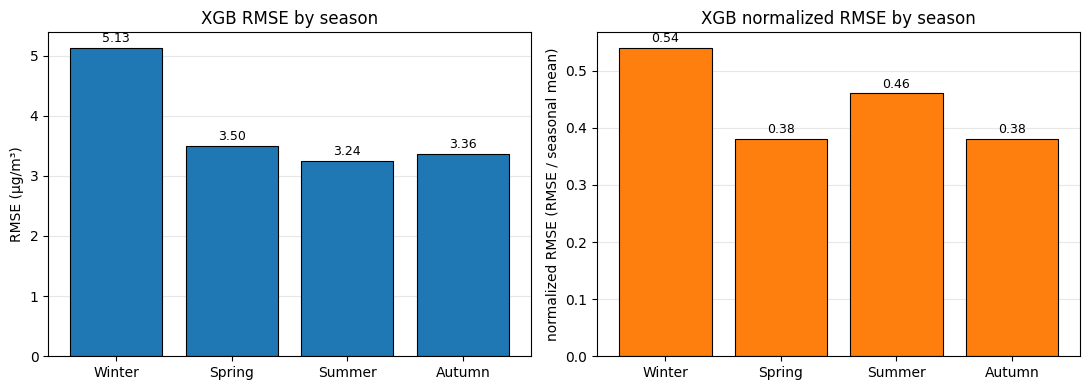

saved: figures\sq4_seasonal_bars.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(season_table["season"], season_table["RMSE"], color="tab:blue",
            edgecolor="black", linewidth=0.8)
for i in range(len(season_table)):
    axes[0].text(i, season_table["RMSE"].iloc[i] + 0.05, "%.2f" % season_table["RMSE"].iloc[i],
                 ha="center", va="bottom", fontsize=9)
axes[0].set_ylabel("RMSE (µg/m³)")
axes[0].set_title("XGB RMSE by season")
axes[0].grid(axis="y", alpha=0.3)
axes[0].set_axisbelow(True)

axes[1].bar(season_table["season"], season_table["nRMSE"], color="tab:orange",
            edgecolor="black", linewidth=0.8)
for i in range(len(season_table)):
    axes[1].text(i, season_table["nRMSE"].iloc[i] + 0.005, "%.2f" % season_table["nRMSE"].iloc[i],
                 ha="center", va="bottom", fontsize=9)
axes[1].set_ylabel("normalized RMSE (RMSE / seasonal mean)")
axes[1].set_title("XGB normalized RMSE by season")
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_axisbelow(True)

fig.tight_layout()
fig.savefig(os.path.join(OUT_FIGURES, "sq4_seasonal_bars.png"), dpi=200, bbox_inches="tight")
plt.show()
print("saved:", os.path.join(OUT_FIGURES, "sq4_seasonal_bars.png"))